Open this notebook in Jupyter or upload it to Colab to run it.

# K-Means Clustering from Scratch

In [1]:
# Dependencies for the lab
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import random
from sklearn import datasets
MAX_ITERATIONS = 100

## Overview
When a dataset has features but no labels, supervised classification is not available. Clustering can instead group observations by similarity.

One of the most straightforward tasks we can perform on a data set without labels is to find groups of data in our dataset which are similar to one another -- what we call clusters.

K-Means is one of the most popular "clustering" algorithms. K-means stores k centroids that it uses to define clusters. A point is considered to be in a particular cluster if it is closer to that cluster's centroid than any other centroid.

K-Means alternates between assigning each point to its nearest centroid and replacing each centroid with the arithmetic mean of its assigned points.

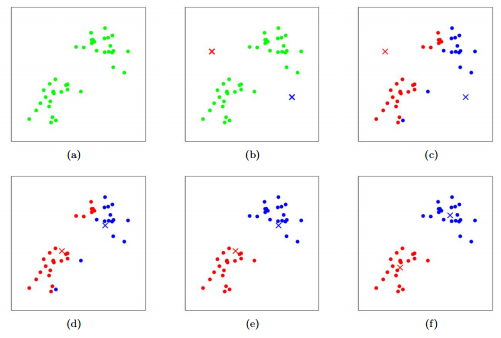

Figure 1: K-means algorithm. Training examples are shown as dots, and cluster centroids are shown as crosses. (a) Original dataset. (b) Random initial cluster centroids. (c-f) Illustration of running two iterations of k-means. In each iteration, we assign each training example to the closest cluster centroid (shown by "painting" the training examples the same color as the cluster centroid to which is assigned); then we move each cluster centroid to the mean of the points assigned to it. Images courtesy of Michael Jordan

## Exercise 1: K-an You Do It? Yes You Can!

In the clustering problem, we are given a training set {x_1, x_2, ... x_m} and want to group the data into a few cohesive "clusters." Here, we are given feature vectors for each data point, x_i which real-values, as usual; but no labels y_i (making this an unsupervised learning problem). Our goal is to predict k centroids and a label c_i for each datapoint. The prediction, c_i is a cluster assignment for x_i . At a high level, the k-means clustering algorithm is as follows:



1.   Initialize **cluster centroids** $μ_1, μ_2, μ_3,....μ_k ∈ ℝ^n$ randomly
2.   Repeat until convergence: {


> For every i, set
>> $c^{(i)}:=arg \underset{j}{min} ||x^{(i)} - μ_j ||^2 $

> For every j, set
>> $μ_j := \frac{∑_{i=1}^m 1 \{c^{(i)} = j\} x^{(i)} }{∑_{i=1}^m 1 \{c^{(i)} = j\}} $

}




Functions to Implement:
*   Get Number of Features
*   Get Centroids
*   Get Random Centroids
*   Should Stop
*   Get Labels
*   K Means

### Function: Get Number of Features
Returns the number of features in the dataset. This corresponds to the number of columns in your dataSet array

In [2]:
def getNumFeatures(dataSet):
    # Find the number of features in the dataset
    numFeatures = dataSet.shape[1]
    return numFeatures

### Function: Get Centroids
Returns k centroids, each with the same number of features as the dataset. Each centroid is the arithmetic mean of the points with that label.

If a cluster is empty, re-initialize its centroid from a randomly selected data point.

In [3]:
def getCentroids(dataSet, labels, k):
    centroids = []
    for cluster_id in range(k):
        members = dataSet[labels == cluster_id]
        if len(members) == 0:
            centroids.append(dataSet[np.random.randint(dataSet.shape[0])])
        else:
            centroids.append(members.mean(axis=0))
    return np.array(centroids)

### Function: Get Labels
Returns a label for each piece of data in the dataset. For each element in the dataset, choose the closest centroid. Make that centroid the element's label.

In [4]:
def getLabels(dataSet, centroids):
    #Assign each datapoint a label in this function according to the centroids
    label = []
    n = dataSet.shape[0]
    m = centroids.shape[0]
    D = np.zeros((n,m))
    
    for xind in range(n):
        for yind in range(m):
            diff = dataSet[xind,:] - centroids[yind,:]
            D [xind, yind] = np.sqrt(np.sum(diff*diff))
            
    labels = np.argmin(D, axis=1)
    return labels

### Function: Get Random Centroids
Randomly initialize the centroids with their corresponding dimensions

In [5]:
def getRandomCentroids(numFeatures, k):
    centroids = np.random.rand(k, numFeatures)
    return centroids

### Function: Should Stop
Returns True or False if K-Means is done. K-Means terminates either because it has run a maximum number of iterations OR the centroids stop changing.

In [6]:
def shouldStop(oldCentroids, centroids, iterations):
    if iterations >= MAX_ITERATIONS or (centroids == oldCentroids).all():
        return True
    else:
        oldCentroids = centroids
        return False

### Function: K Means
K-Means is an algorithm that takes in a dataset and a constant k and returns k centroids (which define clusters of data in the dataset which are similar to one another).

In [7]:
def kmeans(dataSet, k):
    # Initialize centroids randomly
    numFeatures = getNumFeatures(dataSet)
    centroids = getRandomCentroids(numFeatures, k)
    
    # Initialize book keeping vars.
    iterations = 0
    oldCentroids = None
    
    # Run the main k-means algorithm
    while not shouldStop(oldCentroids, centroids, iterations):
        # Save old centroids for convergence test. Book keeping.
        oldCentroids = centroids
        iterations += 1
        
        # Assign labels to each datapoint based on centroids
        labels = getLabels(dataSet, centroids)
        
        # Assign centroids based on datapoint labels
        centroids = getCentroids(dataSet, labels, k)
        
    # We can get the labels too by calling getLabels(dataSet, centroids)
    return centroids

### Plot Function:
Below is a function that plots the dataset with the centroids, it takes in 4 arguments. You will use this function to plot the progress of your K-Means algorithm


1.   title: Graph Title
2.   dataSet: Dataset that's going to be plotted
3.   labels: The labels for the dataset.
4.   centroids: The centroids of the clusters.



In [8]:
def plotDataSet(title, dataSet, labels, centroids):
  plt.title(title)
  array1 = None
  array2 = None
  array3 = None

  index = 0
  for label in labels:
    if label == 0:
      if array1 is None:
        array1 = dataSet[index]
      else:
        array1 = np.vstack((array1, dataSet[index]))
    if label == 1:
      if array2 is None:
        array2 = dataSet[index]
      else:
        array2 = np.vstack((array2, dataSet[index]))
    if label == 2:
      if array3 is None:
        array3 = dataSet[index]
      else:
        array3 = np.vstack((array3, dataSet[index]))
    index = index + 1
  plt.scatter(array1[:,0], array1[:,1], color="red", s=.2)
  plt.scatter(array2[:,0], array2[:,1], color="green", s=.2)
  plt.scatter(array3[:,0], array3[:,1], color="blue", s=.2)

  plt.scatter(centroids[0][0], centroids[0][1], color="darkred", marker='x', s=50)
  plt.scatter(centroids[1][0], centroids[1][1], color="darkgreen", marker='x', s=50)
  plt.scatter(centroids[2][0], centroids[2][1], color="midnightblue", marker='x', s=50)
  plt.show()

## Exercise 2
Generate a dataset called blobs with the following code:

In [9]:
 from sklearn import datasets
 n_samples = 1500
 blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)[0]

* Run your kmeans algorithm on this dataset with k=3

* Show a scatter plot after iteration 0:

  * Plot the data

  * Color the plots using the estimated categories as labels (see Figure 1 above for example)

* Show a scatter plot after iteration 9, if the algorithm converges before 9, don't worry about plotting the 9th plot:

  * Plot the data

  * Color the plots using the estimated categories as labels (see Figure 1 above for example)

* Show a scatter plot after algorithm has terminated

  * Plot the data

  * Color the plots using the estimated categories as labels (see Figure 1 above for example)


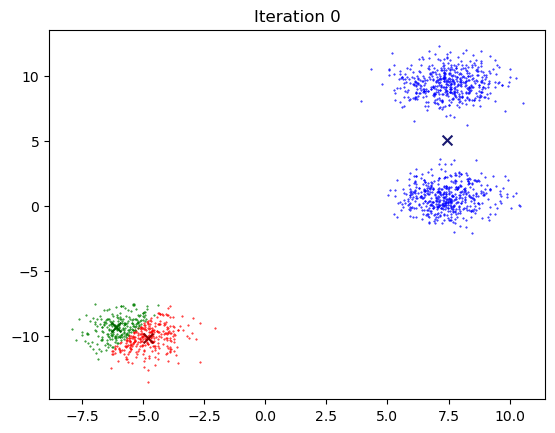

In [10]:
MAX_ITERATIONS = 0
centroids2 = kmeans(blobs, 3)
labels2 = getLabels(blobs, centroids2)
plotDataSet("Iteration 0", blobs, labels2, centroids2)

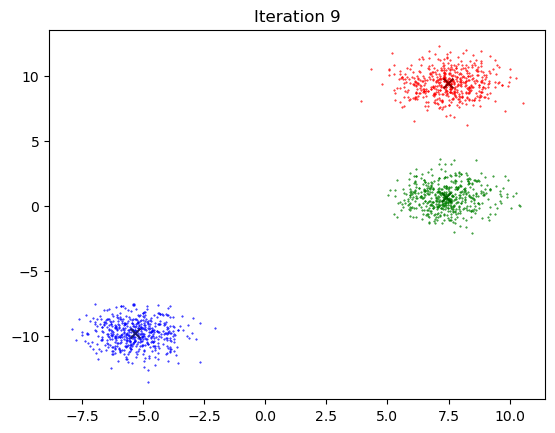

In [11]:
MAX_ITERATIONS = 9
centroids2 = kmeans(blobs, 3)
labels2 = getLabels(blobs, centroids2)
plotDataSet("Iteration 9", blobs, labels2, centroids2)

What do you notice about the predicted clusters as algorithm progresses?

>The predicted clusters accurately converge to the 3 clusters visible in the plot. It also converges fairly quickly, because the clusters have little noise and are well-defined.

Does the number of centroids, k=3 fit the data?

>Yes, k=3 fits this data well - there are 3 distinct clusters that are each represented well from each centroid.

Discuss the quality of the clustering.

>The quality of the clustering is very good, even nearly perfect. Because the clusters are very separated and have little noise, especially the one centered around (-5.5,-10), the K-means clusters group the data points very well.

## Exercise 3
Generate a dataset called noisy moons with the following code:

In [12]:
from sklearn import datasets
n_samples = 1500
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=.05)[0]

* Run your kmeans algorithm on this dataset with k=3

* Show a scatter plot after iteration 0:

  * Plot the data

  * Color the plots using the estimated categories as labels (see Figure 1 above for example)

* Show a scatter plot after iteration 9:

  * Plot the data

  * Color the plots using the estimated categories as labels (see Figure 1 above for example)

* Show a scatter plot after algorithm has terminated

  * Plot the data

  * Color the plots using the estimated categories as labels (see Figure 1 above for example)


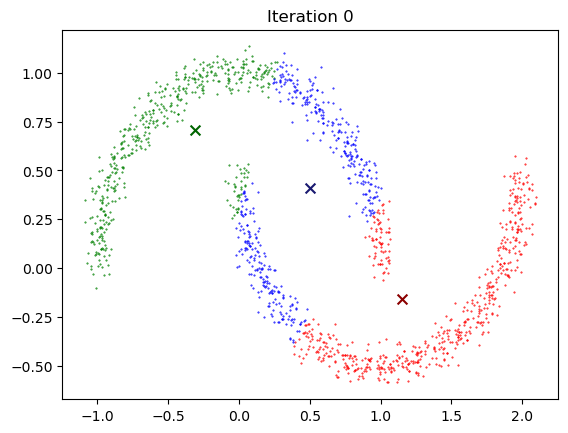

In [13]:
MAX_ITERATIONS = 0
centroids3 = kmeans(noisy_moons, 3)
labels3 = getLabels(noisy_moons, centroids3)
plotDataSet("Iteration 0", noisy_moons, labels3, centroids3)

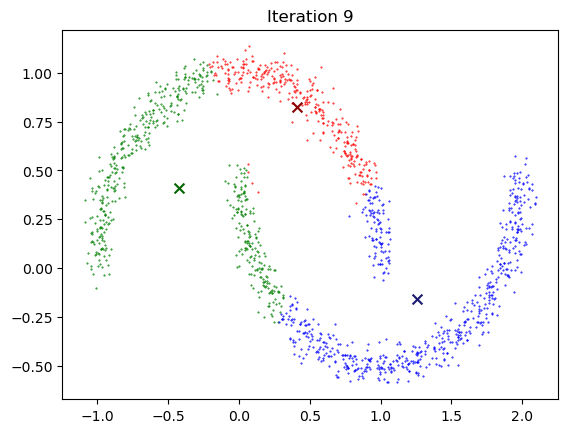

In [14]:
MAX_ITERATIONS = 9
centroids3 = kmeans(noisy_moons, 3)
labels3 = getLabels(noisy_moons, centroids3)
plotDataSet("Iteration 9", noisy_moons, labels3, centroids3)

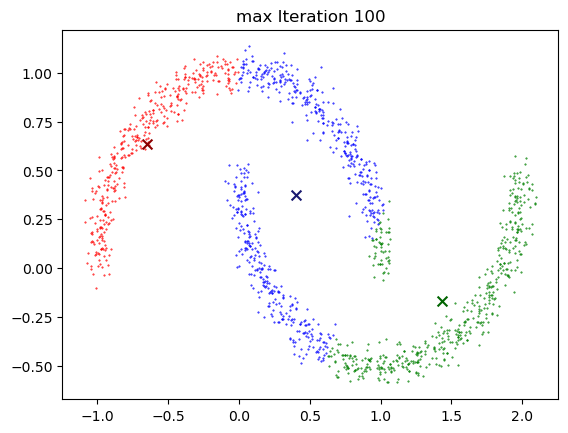

In [15]:
MAX_ITERATIONS = 100
centroids3 = kmeans(noisy_moons, 3)
labels3 = getLabels(noisy_moons, centroids3)
plotDataSet("max Iteration 100", noisy_moons, labels3, centroids3)

What do you notice about the predicted clusters as algorithm progresses?

>The predicted clusters seem to move around a bit from iteration 0 to iteration 9, then, as the iterations continue, move back to what the predictions looked like at iteration 0, but the centroids have changed places. The clusters seem to struggle to converge to a single prediction.

Does the number of centroids, k=3 fit the data?

>It seems that k=3 does not fit the data. When plotted, the data show 2 distinct moon-shaped clusters, rather than 3.

Discuss the quality of the clustering.

> The quality of the clustering is not very good. The number of centroids does not fit the data, and the k-means method of clustering by proximity does not fit the shape of the clusters. The clusters don't converge and grab points across clusters, resulting in a flawed interpretation.

## Exercise 4
Discuss what you learned below

>I learned how simple some of these methods of clustering can be, and how complex clustering can become. The k-means method of selecting a centroid(s) and centering it in the points with the corresponding label is quite simple conceptually, and works well for typical clusters. But, as the shapes get more advanced and points from different clusters overlap each other, a different clustering method should be used.